# AAV5 fitting protocol -- manual playground, GT-vs-sim overlay, ProfileMLP recovery

Same recipe as `AAV9_fitting_protocol.ipynb`'s sections 5-7, applied to the real `aav5.csv`
library instead of `aav9.csv`. Sections 3 ("Part 1" repeatability check) and 4 ("Part 2"
hyperparameter search) are intentionally NOT reproduced here -- that random search alone took
~11 minutes on `aav9`'s 68,776 sequences, and isn't worth re-running twice more just to
reach the same manual/MLP sections; run it directly in `AAV9_fitting_protocol.ipynb` (sections
3-4) if a full search is wanted for this dataset too. The baseline hyperparameters below
(`mu=50, T_viab=0.8, noise_viab=0.5, D=1e9`) are the same fixed defaults as `AAV9_fitting_protocol.ipynb`'s
own baseline (section 2), not a value tuned for `aav5.csv` specifically.

**Note**: `aav5.csv` has extra columns aav9.csv doesn't (plasmid, vector1, vector2, plasmid_norm, vector1_norm, vector2_norm) -- AAV5's `error`
column is a real varying per-sequence value here (not aav9's constant `0.1` placeholder), and
there are raw plasmid/vector count columns too. Neither is used below (this notebook mirrors
aav9's sections 5-7 as directly as possible), but they could enable a more direct real-noise
calibration than what was possible for aav9 -- worth a separate look if useful.

## 0. Setup

In [1]:
import sys, os

# This notebook lives in "Modelization_V1/notebooks/aav_viability_test/", two levels below
# analysisV1.py / sequence_classesV1.py -- same sys.path convention as AAV9_fitting_protocol.ipynb.
sys.path.insert(0, os.path.abspath("../.."))
sys.path.insert(0, os.path.abspath("."))
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"  # must be set before jax initializes

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from tqdm.auto import tqdm

from analysisV1 import AA_LABELS, pearson
from sequence_classesV1 import ProtocolV3
from initialize_weights import NUM_AMINO_ACIDS, NUM_POSITIONS

print(f"JAX backend: {jax.default_backend()} -- devices: {jax.devices()}")

message = "AAV5 fitting protocol 1.0"


/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


JAX backend: gpu -- devices: [CudaDevice(id=0)]


## 1. Real AAV5 data: sequences + real `target`

In [2]:
df = pd.read_csv("aav5.csv")
print(f"{len(df):,} variants, columns: {list(df.columns)}")

lengths = df["sequence"].str.len().unique()
assert len(lengths) == 1, f"expected a single sequence length, got {lengths}"
assert int(lengths[0]) == NUM_POSITIONS

print(f"`error` column: min={df['error'].min():.4g}  max={df['error'].max():.4g}  "
      f"(real per-sequence values here, unlike aav9.csv's constant 0.1 placeholder)")

lut = np.zeros(256, dtype=np.int64)
for i, aa in enumerate(AA_LABELS):
    lut[ord(aa)] = i

seq_bytes   = np.frombuffer("".join(df["sequence"]).encode("ascii"), dtype=np.uint8)
seq_matrix  = lut[seq_bytes].reshape(len(df), NUM_POSITIONS)
real_target = df["target"].to_numpy()

sequences = jnp.asarray(seq_matrix)
d0        = sequences.shape[0]

print(f"seq_matrix shape: {seq_matrix.shape}  (num_sequences, num_positions)")
print(f"d0 = {d0:,} real AAV5 library sequences")


737,587 variants, columns: ['sequence', 'target', 'error', 'plasmid', 'vector1', 'vector2', 'plasmid_norm', 'vector1_norm', 'vector2_norm']
`error` column: min=0.001387  max=2  (real per-sequence values here, unlike aav9.csv's constant 0.1 placeholder)
seq_matrix shape: (737587, 7)  (num_sequences, num_positions)
d0 = 737,587 real AAV5 library sequences


## 2. Ground-truth weights + baseline protocol config

`F_viab`/`J_viab` are the ProfileMLP recovery from `AAV5_profile_model.ipynb`, fit on this exact
`aav5.csv` dataset -- loaded directly from `lib/aav5_F_viab_mlp.npy`/`lib/aav5_J_viab_mlp.npy`
(no dedicated `load_F_viab_aav5_mlp()` helper exists in `initialize_weights.py`, unlike aav9 --
that module is aav9-specific by name/design).

`F_sel`/`J_sel` are set to zero: `loop_DE()` computes `lambda0p`/`lambda2p` (-> `target1`) BEFORE
`selectivity()` is ever called, so `F_sel`/`J_sel` cannot influence `target1` at all -- same
reasoning as `AAV9_fitting_protocol.ipynb` section 2.

Baseline config is the SAME fixed defaults as `AAV9_fitting_protocol.ipynb`: `mu=50`,
`T_viab=0.8`, `noise_viab=0.5`, `D=1e9` -- not tuned for `aav5.csv`'s own `d0={d0:,}` (very
different from aav9's 68,776), so `D/d0` (reads/sequence) will differ a lot between notebooks.

In [3]:
LIB_DIR = os.path.abspath("../../lib")
F_viab = jnp.asarray(np.load(os.path.join(LIB_DIR, "aav5_F_viab_mlp.npy")))
J_viab = jnp.asarray(np.load(os.path.join(LIB_DIR, "aav5_J_viab_mlp.npy")))
assert F_viab.shape == (NUM_AMINO_ACIDS, NUM_POSITIONS)
assert J_viab.shape == (NUM_POSITIONS, NUM_POSITIONS, NUM_AMINO_ACIDS, NUM_AMINO_ACIDS)

F_sel = jnp.zeros_like(F_viab)
J_sel = jnp.zeros_like(J_viab)

RHO_REF          = 1e-3
MU_FIXED         = 50
T_VIAB_FIXED     = 0.8
NOISE_VIAB_FIXED = 0.5
D_FIXED          = 1e9
DILUTION_FACTOR  = 10
T_SEL_FIXED      = 1.0   # unused by target1, kept at the project default
eps              = 1.0

N1_FIXED = MU_FIXED * d0 / RHO_REF
N0_FIXED = N1_FIXED * 10

protocol = ProtocolV3(multinomialNGS=True, N0=N0_FIXED, N1=N1_FIXED,
        dilution_factor=DILUTION_FACTOR, sequences=sequences, D=D_FIXED,
        F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
        noise_viab=NOISE_VIAB_FIXED, noise_sel=0.0, T_sel=T_SEL_FIXED, T_viab=T_VIAB_FIXED,
        )

print(f"mu = {protocol._rho * protocol.N1 / d0:.2f}   N1={N1_FIXED:.3e}   N0={N0_FIXED:.3e}")
print(f"D/d0 (reads/sequence at baseline) = {D_FIXED / d0:.1f}")


mu = 50.00   N1=3.688e+10   N0=3.688e+11
D/d0 (reads/sequence at baseline) = 1355.8


### 2a. `viability_target1` helper

Same helper as `AAV9_fitting_protocol.ipynb` section 3 -- defined here directly (rather than
inside a repeatability-check section, which this notebook skips) since sections 5-7 below need
it. Resets `lambda0` before every call, since `loop_DE()` depletes it in place.

In [4]:
def viability_target1(protocol, eps=eps):
    """Runs one loop_DE() round and returns target1 = log((lambda2p+eps)/(lambda0p+eps)), the
    viability log-enrichment estimated from NGS reads only (same formula as
    AAV9_fitting_protocol.ipynb / RegressionV1.build_multi_round_dataset)."""
    protocol.lambda0 = jnp.full(protocol.d0, protocol.N0 / protocol.d0)
    _bio_row, ngs_row = protocol.loop_DE()
    lambda0p, lambda2p, _lambda3p = (np.asarray(a) for a in ngs_row)
    return np.log((lambda2p + eps) / (lambda0p + eps))


## 2b. GT score distribution + `R_REAL`

`viab_score_GT = compute_score(F_viab, J_viab)` -- deterministic F+J score, no protocol noise.
`R_REAL = pearson(real_target, viab_score_GT)` -- how much AAV5's real experimental noise
degrades agreement with the GT model (same definition as `AAV9_fitting_protocol.ipynb` section
4, computed directly here since section 4's fuller writeup is skipped).

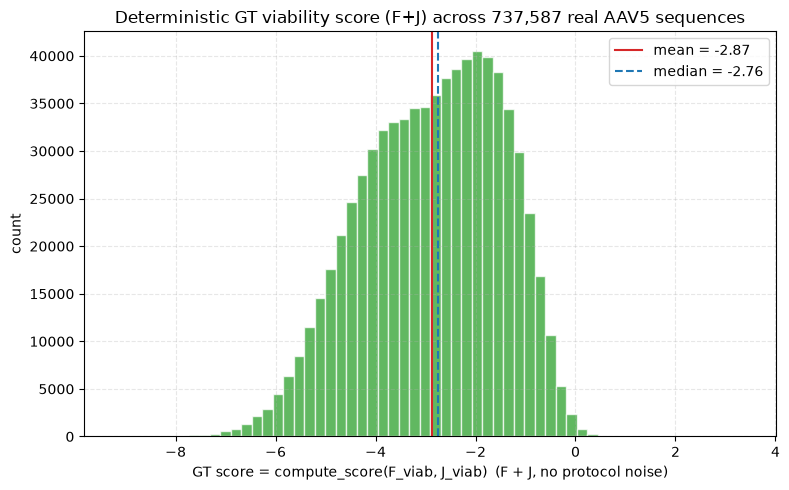

GT score: min=-9.20  max=3.38  mean=-2.87  std=1.39
R_REAL = r(real aav5 target, deterministic GT score) = 0.395


In [5]:
viab_score_GT = np.asarray(protocol.compute_score(F_viab, J_viab))
R_REAL = pearson(real_target, viab_score_GT)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(viab_score_GT, bins=60, color="tab:green", alpha=0.75, edgecolor="white")
ax.axvline(viab_score_GT.mean(), color="tab:red", linestyle="-", label=f"mean = {viab_score_GT.mean():.2f}")
ax.axvline(np.median(viab_score_GT), color="tab:blue", linestyle="--", label=f"median = {np.median(viab_score_GT):.2f}")
ax.set_xlabel("GT score = compute_score(F_viab, J_viab)  (F + J, no protocol noise)")
ax.set_ylabel("count")
ax.set_title(f"Deterministic GT viability score (F+J) across {d0:,} real AAV5 sequences")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()

print(f"GT score: min={viab_score_GT.min():.2f}  max={viab_score_GT.max():.2f}  "
      f"mean={viab_score_GT.mean():.2f}  std={viab_score_GT.std():.2f}")
print(f"R_REAL = r(real aav5 target, deterministic GT score) = {R_REAL:.3f}")


## 5. Manual playground: tweak hyperparameters and weights by hand

Edit the block at the top of the cell below (hyperparameters, and/or `F_VIAB_MANUAL`/
`J_VIAB_MANUAL` if you want to try different weights) and re-run -- it always sets `protocol`'s
full state from these variables, so nothing is left over between runs to worry about.

No search was run in this notebook (see the top-level note), so this starts from the SAME fixed
baseline as section 2, not a pre-found best candidate -- tune by hand from here.

`F_sel`/`J_sel` aren't included here: as throughout this notebook, `loop_DE()` computes
`lambda0p`/`lambda2p` (-> `target1`) BEFORE `selectivity()` runs, so they can't affect what's
plotted below regardless of their value.

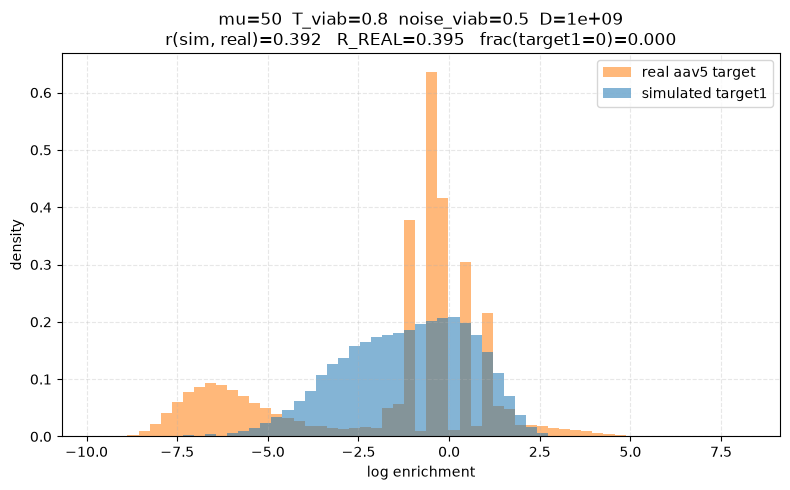

In [6]:
# ---- Edit these, then re-run this cell ----
MU_MANUAL         = MU_FIXED
T_VIAB_MANUAL     = T_VIAB_FIXED
NOISE_VIAB_MANUAL = NOISE_VIAB_FIXED
D_MANUAL          = D_FIXED
F_VIAB_MANUAL     = F_viab   # swap for another (num_amino_acids, num_positions) array to test different weights
J_VIAB_MANUAL     = J_viab   # swap for another (num_positions, num_positions, num_amino_acids, num_amino_acids) array
# --------------------------------------------

protocol.F_viab      = F_VIAB_MANUAL
protocol.J_viab      = J_VIAB_MANUAL
protocol.N1          = float(MU_MANUAL * d0 / RHO_REF)
protocol.N0          = float(protocol.N1 * 10)
protocol._T_viab     = float(T_VIAB_MANUAL)
protocol.noise_viab  = float(NOISE_VIAB_MANUAL)
protocol.D           = float(D_MANUAL)

target1_manual   = viability_target1(protocol)
r_manual         = pearson(target1_manual, real_target)
frac_zero_manual = float(np.mean(target1_manual == 0.0))

fig, ax = plt.subplots(figsize=(8, 5))
bins = np.linspace(min(real_target.min(), target1_manual.min()),
                    max(real_target.max(), target1_manual.max()), 60)
ax.hist(real_target,    bins=bins, alpha=0.55, density=True, color="tab:orange", label="real aav5 target")
ax.hist(target1_manual, bins=bins, alpha=0.55, density=True, color="tab:blue",   label="simulated target1")
ax.set_xlabel("log enrichment")
ax.set_ylabel("density")
ax.set_title(f"mu={MU_MANUAL:.3g}  T_viab={T_VIAB_MANUAL:.3g}  noise_viab={NOISE_VIAB_MANUAL:.3g}  D={D_MANUAL:.3g}\n"
             f"r(sim, real)={r_manual:.3f}   R_REAL={R_REAL:.3f}   frac(target1=0)={frac_zero_manual:.3f}")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()


## 6. Overlay: GT score vs the manual playground's simulated log enrichment

`viab_score_GT` (section 2b, deterministic F+J, no noise) vs `target1_manual` (section 5, one
stochastic `loop_DE()` run at the hand-picked hyperparameters above).

r(simulated target1, GT score) = 0.991   (unaffected by the T_viab rescaling -- Pearson r is invariant to dividing by a positive constant)
R_REAL = 0.395   (target this should land near, per section 2b)


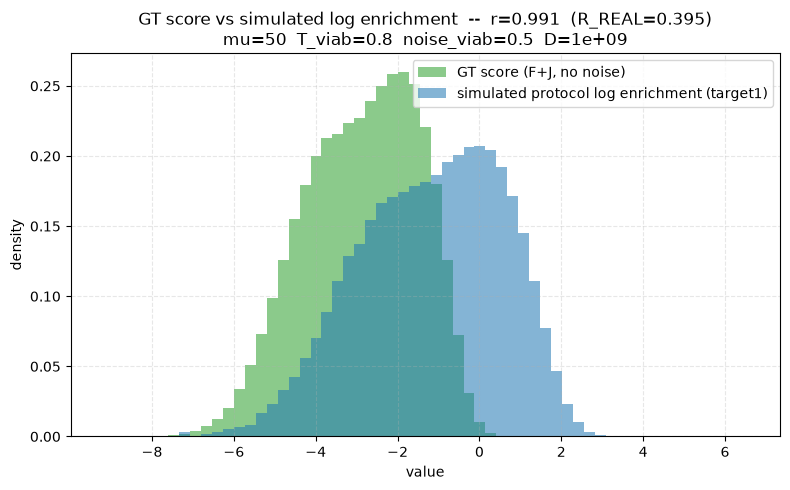

In [7]:
r_manual_vs_GT = pearson(target1_manual, viab_score_GT)
print(f"r(simulated target1, GT score) = {r_manual_vs_GT:.3f}   "
      f"(unaffected by the T_viab rescaling -- Pearson r is invariant to dividing by a positive constant)")
print(f"R_REAL = {R_REAL:.3f}   (target this should land near, per section 2b)")

fig, ax = plt.subplots(figsize=(8, 5))
bins_score = np.linspace(min(viab_score_GT.min(), target1_manual.min()),
                          max(viab_score_GT.max(), target1_manual.max()), 60)
ax.hist(viab_score_GT,  bins=bins_score, alpha=0.55, density=True, color="tab:green", label="GT score (F+J, no noise)")
ax.hist(target1_manual, bins=bins_score, alpha=0.55, density=True, color="tab:blue",  label="simulated protocol log enrichment (target1)")
ax.set_xlabel("value")
ax.set_ylabel("density")
ax.set_title(f"GT score vs simulated log enrichment  --  r={r_manual_vs_GT:.3f}  (R_REAL={R_REAL:.3f})\n"
             f"mu={MU_MANUAL:.3g}  T_viab={T_VIAB_MANUAL:.3g}  noise_viab={NOISE_VIAB_MANUAL:.3g}  D={D_MANUAL:.3g}")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()


## 7. ProfileMLP trained on 25,000 real AAV5 variants -- held-out test predictions

Same architecture/training convention as `AAV9_fitting_protocol.ipynb` section 7 (one-hot
7x20=140 input, 2 hidden layers with BatchNorm+Dropout+GELU, AdamW + cosine-decay LR + early
stopping), trained directly on the REAL `target` column, tested on sequences it never saw.

In [8]:
from sklearn.model_selection import train_test_split
from flax import nnx
from typing import Optional
import optax

N_TRAIN_MLP = 25_000

seq_oh = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[seq_matrix].reshape(d0, -1)

idx_train_mlp, idx_test_mlp = train_test_split(np.arange(d0), train_size=N_TRAIN_MLP, random_state=0)
y_train_mlp, y_test_mlp      = real_target[idx_train_mlp], real_target[idx_test_mlp]
X_train_full_mlp, X_test_mlp = seq_oh[idx_train_mlp],       seq_oh[idx_test_mlp]

print(f"train: {len(idx_train_mlp):,}   test: {len(idx_test_mlp):,}")


train: 25,000   test: 712,587


In [9]:
class ProfileMLP(nnx.Module):
    """
    MLP over the one-hot encoded per-position sequence (L=7 positions x A=20 amino acids
    -> 140 indicator features) -> scalar score. Same architecture as
    AAV9_fitting_protocol.ipynb / AAV9_profile_model.ipynb.
    """

    def __init__(self, input_dim: int, hidden_dims: tuple[int, int] = (128, 64),
                 dropout_rate: float = 0.1, *, rngs: nnx.Rngs):
        h1, h2 = hidden_dims
        self.linear1    = nnx.Linear(input_dim, h1, rngs=rngs)
        self.batchnorm1 = nnx.BatchNorm(h1, use_running_average=False, rngs=rngs)
        self.dropout1   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear2    = nnx.Linear(h1, h2, rngs=rngs)
        self.batchnorm2 = nnx.BatchNorm(h2, use_running_average=False, rngs=rngs)
        self.dropout2   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear3    = nnx.Linear(h2, 1, rngs=rngs)

    def __call__(self, x: jax.Array, *, train: bool, rngs: Optional[nnx.Rngs] = None) -> jax.Array:
        x = self.linear1(x)
        x = self.batchnorm1(x, use_running_average=not train)
        x = self.dropout1(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)

        x = self.linear2(x)
        x = self.batchnorm2(x, use_running_average=not train)
        x = self.dropout2(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)

        return self.linear3(x).squeeze(-1)


In [10]:
@nnx.jit
def train_step(model, optimizer, x, y, rngs):
    def loss_fn(model, rngs):
        y_pred = model(x, train=True, rngs=rngs)
        return jnp.mean((y_pred - y) ** 2)

    loss, grads = nnx.value_and_grad(loss_fn)(model, rngs)
    optimizer.update(model, grads)
    return loss


@nnx.jit
def eval_step(model, x, y):
    y_pred = model(x, train=False)
    return jnp.mean((y_pred - y) ** 2)


@nnx.jit
def predict_scores(model, x):
    return model(x, train=False)


@nnx.scan(in_axes=(nnx.Carry, 0, 0), out_axes=(nnx.Carry, 0))
def train_epoch_scan(carry, xb, yb):
    """Fuses one epoch's mini-batch train_step calls into a single compiled nnx.scan
    instead of a Python for-loop issuing one XLA dispatch per batch."""
    model, optimizer, rngs = carry
    loss = train_step(model, optimizer, xb, yb, rngs)
    return (model, optimizer, rngs), loss


def train_profile_mlp(X_train, y_train, X_val, y_val, hidden_dims=(128, 64),
                       dropout_rate=0.1, epochs=300, batch_size=256,
                       peak_lr=1e-3, final_lr=1e-5, weight_decay=0,
                       patience=20, seed=0, verbose=True, model=None):
    rngs = nnx.Rngs(seed)
    if model is None:
        model = ProfileMLP(input_dim=X_train.shape[1], hidden_dims=hidden_dims,
                            dropout_rate=dropout_rate, rngs=rngs)

    n_train         = X_train.shape[0]
    steps_per_epoch = max(n_train // batch_size, 1)
    total_steps     = steps_per_epoch * epochs

    lr_schedule_fn = optax.warmup_cosine_decay_schedule(
        init_value=0., peak_value=peak_lr,
        warmup_steps=int(total_steps * 0.1),
        decay_steps=int(total_steps * 0.9),
        end_value=final_lr,
    )
    optimizer = nnx.Optimizer(
        model, optax.adamw(learning_rate=lr_schedule_fn, weight_decay=weight_decay), wrt=nnx.Param
    )

    X_train, y_train = jnp.asarray(X_train), jnp.asarray(y_train)
    X_val,   y_val   = jnp.asarray(X_val),   jnp.asarray(y_val)

    shuffle_key = jax.random.key(seed)
    best_val, best_state, bad_epochs = float("inf"), None, 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in tqdm(range(epochs), desc="Training ProfileMLP", disable=not verbose):
        shuffle_key, perm_key = jax.random.split(shuffle_key)
        perm      = jax.random.permutation(perm_key, n_train)
        batch_idx = perm[: steps_per_epoch * batch_size].reshape(steps_per_epoch, batch_size)

        (model, optimizer, rngs), step_losses = train_epoch_scan(
            (model, optimizer, rngs), X_train[batch_idx], y_train[batch_idx]
        )
        train_loss = float(jnp.mean(step_losses))
        val_loss   = float(eval_step(model, X_val, y_val))

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val - 1e-5:
            best_val, bad_epochs = val_loss, 0
            best_state = nnx.state(model)
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch} (best val MSE={best_val:.4f})")
                break

    nnx.update(model, best_state)
    return model, history


In [11]:
def split_train_val(X, y, val_frac=0.15, seed=0):
    rng   = np.random.default_rng(seed)
    idx   = rng.permutation(len(X))
    n_val = int(len(X) * val_frac)
    val_idx, train_idx = idx[:n_val], idx[n_val:]
    return X[train_idx], y[train_idx], X[val_idx], y[val_idx]

Xtr_mlp, ytr_mlp, Xva_mlp, yva_mlp = split_train_val(X_train_full_mlp, y_train_mlp, val_frac=0.15, seed=0)
print(f"ProfileMLP -- train: {len(Xtr_mlp):,}  val: {len(Xva_mlp):,}  test: {len(X_test_mlp):,}")

model_mlp, hist_mlp = train_profile_mlp(Xtr_mlp, ytr_mlp, Xva_mlp, yva_mlp, seed=0)


ProfileMLP -- train: 21,250  val: 3,750  test: 712,587


Training ProfileMLP:  11%|█▏        | 34/300 [00:04<00:36,  7.32it/s]

Early stopping at epoch 34 (best val MSE=7.6086)


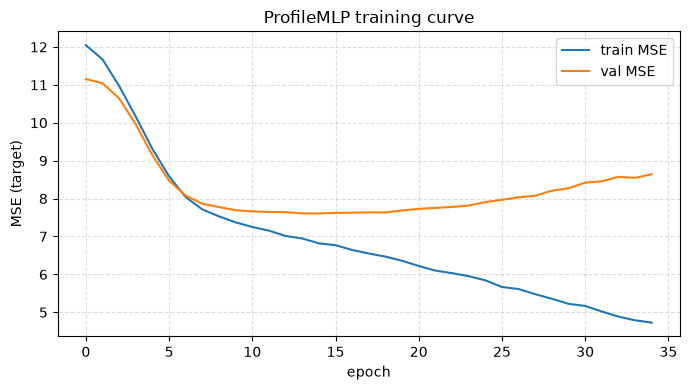

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(hist_mlp["train_loss"], label="train MSE")
ax.plot(hist_mlp["val_loss"],   label="val MSE")
ax.set_xlabel("epoch")
ax.set_ylabel("MSE (target)")
ax.set_title("ProfileMLP training curve")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
fig.tight_layout()
plt.show()


Held-out test set (712,587 variants): r(real target, MLP prediction) = 0.277


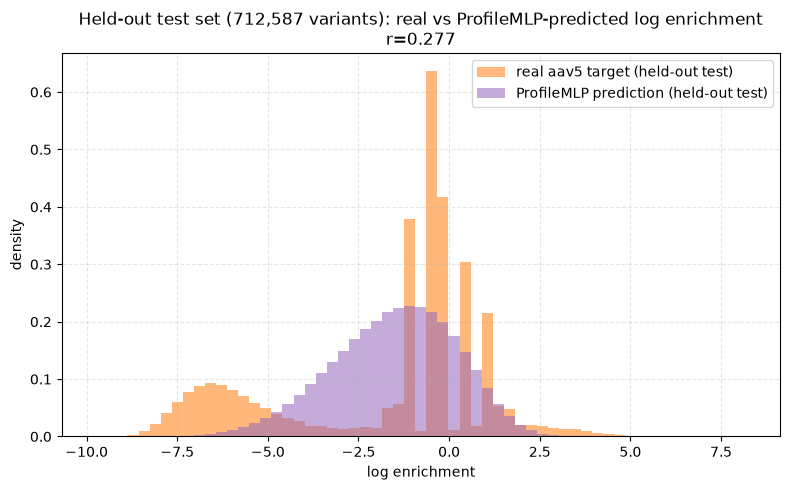

In [13]:
def batched_predict(model, X_oh, batch_size=8192):
    chunks = []
    for start in range(0, X_oh.shape[0], batch_size):
        chunk = jnp.asarray(X_oh[start : start + batch_size])
        chunks.append(np.asarray(predict_scores(model, chunk)))
    return np.concatenate(chunks)

pred_test_mlp = batched_predict(model_mlp, X_test_mlp)
r_test_mlp    = pearson(y_test_mlp, pred_test_mlp)
print(f"Held-out test set ({len(y_test_mlp):,} variants): r(real target, MLP prediction) = {r_test_mlp:.3f}")

fig, ax = plt.subplots(figsize=(8, 5))
bins_mlp = np.linspace(min(y_test_mlp.min(), pred_test_mlp.min()),
                        max(y_test_mlp.max(), pred_test_mlp.max()), 60)
ax.hist(y_test_mlp,    bins=bins_mlp, alpha=0.55, density=True, color="tab:orange", label="real aav5 target (held-out test)")
ax.hist(pred_test_mlp, bins=bins_mlp, alpha=0.55, density=True, color="tab:purple", label="ProfileMLP prediction (held-out test)")
ax.set_xlabel("log enrichment")
ax.set_ylabel("density")
ax.set_title(f"Held-out test set ({len(y_test_mlp):,} variants): real vs ProfileMLP-predicted log enrichment\n"
             f"r={r_test_mlp:.3f}")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()
